In [1]:
import akshare as ak
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# 图标中文显示
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False
print("库导入成功")

库导入成功


In [2]:
# 拉取平安银行（000001）前复权日线数据
df = ak.stock_zh_a_hist(symbol="000001", adjust="qfq")

# 看一下数据长什么样
print(df.shape)   # 有多少行、多少列
print(df.head())  # 看前5行

(8363, 12)
           日期    股票代码    开盘    收盘    最高    最低  成交量      成交额   振幅   涨跌幅   涨跌额  \
0  1991-04-03  000001 -2.72 -2.72 -2.72 -2.72    1   5000.0  0.0  2.86  0.08   
1  1991-04-04  000001 -2.73 -2.73 -2.73 -2.73    3  15000.0  0.0 -0.37 -0.01   
2  1991-04-05  000001 -2.73 -2.73 -2.73 -2.73    2  10000.0  0.0  0.00  0.00   
3  1991-04-06  000001 -2.73 -2.73 -2.73 -2.73    7  34000.0  0.0  0.00  0.00   
4  1991-04-08  000001 -2.73 -2.73 -2.73 -2.73    2  10000.0  0.0  0.00  0.00   

   换手率  
0  0.0  
1  0.0  
2  0.0  
3  0.0  
4  0.0  


In [3]:
# 只保留我们需要的列
df = df[["日期", "开盘", "收盘", "最高", "最低", "成交量"]]

# 把日期设为索引
df = df.set_index("日期")

# 把索引转成日期格式
df.index = pd.to_datetime(df.index)

# 只取最近3年的数据，早期负数价格不要
df = df[df.index >= "2022-01-01"]

print(df.shape)
print(df.head())

(1023, 5)
               开盘     收盘     最高     最低      成交量
日期                                             
2022-01-04  14.40  14.58  14.58  14.10  1169259
2022-01-05  14.50  15.07  15.14  14.47  1961998
2022-01-06  15.03  15.04  15.19  14.92  1107885
2022-01-07  15.02  15.12  15.20  14.98  1126631
2022-01-10  15.21  15.11  15.34  14.95   909774


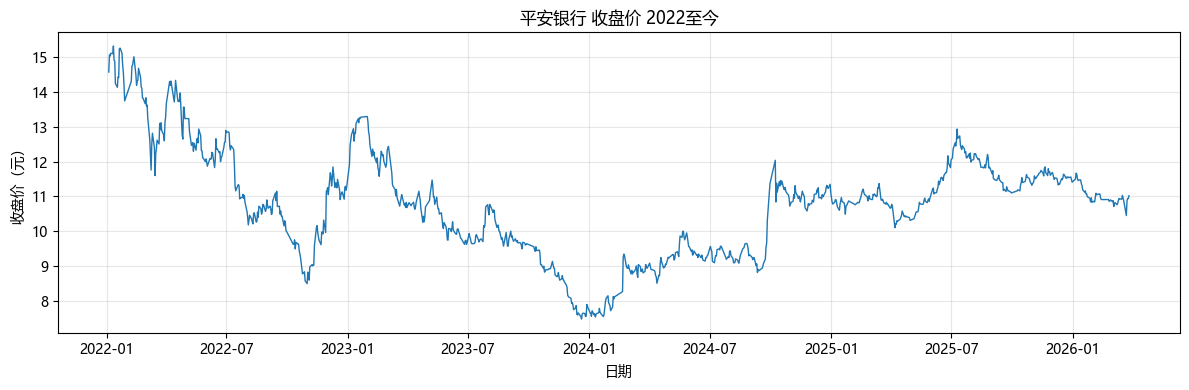

In [4]:
plt.figure(figsize=(12, 4))
plt.plot(df.index, df["收盘"], linewidth=1)
plt.title("平安银行 收盘价 2022至今")
plt.xlabel("日期")
plt.ylabel("收盘价（元）")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [5]:
# 检查有没有缺失值
print("缺失值统计：")
print(df.isnull().sum())

# 检查数据连续性
print(f"\n总交易日数：{len(df)}")
print(f"起始日期：{df.index.min()}")
print(f"结束日期：{df.index.max()}")

缺失值统计：
开盘     0
收盘     0
最高     0
最低     0
成交量    0
dtype: int64

总交易日数：1023
起始日期：2022-01-04 00:00:00
结束日期：2026-03-27 00:00:00


In [6]:
# 计算20日动量因子
momentum = df["收盘"] / df["收盘"].shift(20) - 1

# 看一下结果
print(momentum.head(25))

日期
2022-01-04         NaN
2022-01-05         NaN
2022-01-06         NaN
2022-01-07         NaN
2022-01-10         NaN
2022-01-11         NaN
2022-01-12         NaN
2022-01-13         NaN
2022-01-14         NaN
2022-01-17         NaN
2022-01-18         NaN
2022-01-19         NaN
2022-01-20         NaN
2022-01-21         NaN
2022-01-24         NaN
2022-01-25         NaN
2022-01-26         NaN
2022-01-27         NaN
2022-01-28         NaN
2022-02-07         NaN
2022-02-08    0.011660
2022-02-09   -0.019244
2022-02-10   -0.008644
2022-02-11   -0.006614
2022-02-14   -0.040371
Name: 收盘, dtype: float64


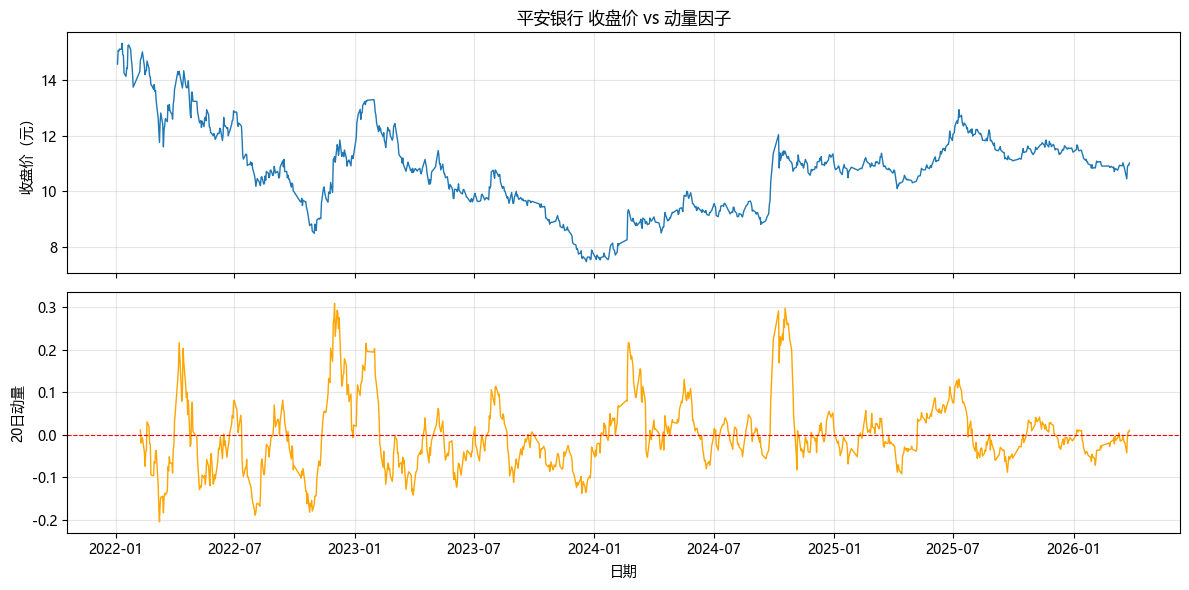

In [7]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

# 上图：收盘价
ax1.plot(df.index, df["收盘"], linewidth=1)
ax1.set_title("平安银行 收盘价 vs 动量因子")
ax1.set_ylabel("收盘价（元）")
ax1.grid(True, alpha=0.3)

# 下图：动量因子
ax2.plot(momentum.index, momentum, linewidth=1, color="orange")
ax2.axhline(y=0, color="red", linewidth=0.8, linestyle="--")
ax2.set_ylabel("20日动量")
ax2.set_xlabel("日期")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [8]:
# 第一步：去极值（MAD法）
median = momentum.median()
mad = (momentum - median).abs().median()

momentum_clean = momentum.clip(median - 5*mad, median + 5*mad)

print(f"原始动量因子范围：{momentum.min():.4f} 到 {momentum.max():.4f}")
print(f"去极值后范围：{momentum_clean.min():.4f} 到 {momentum_clean.max():.4f}")

原始动量因子范围：-0.2043 到 0.3097
去极值后范围：-0.2043 到 0.1862
